In [1]:
import torch
torch.cuda.is_available(), torch.version.cuda, torch.cuda.get_device_name(0)


(True, '11.8', 'NVIDIA GeForce RTX 4050 Laptop GPU')

Scanning data/UCF50...
Found 6681 videos in 50 classes.
Train samples: 5344
Test samples: 1337

Loading one batch... (this might take a few seconds)
Video Batch Shape: torch.Size([4, 3, 16, 112, 112])
Labels Batch: tensor([46, 41, 10, 15])


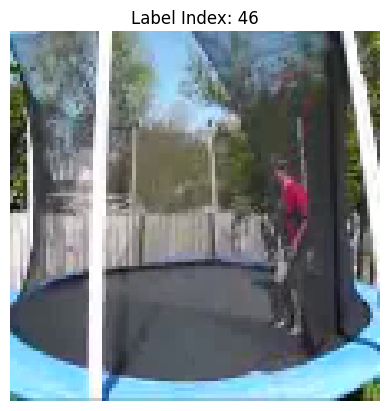

In [2]:
# FILE: 01_Data_Pipeline.ipynb

import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Import the module we just created
from utils.dataset_loader import UCF50Dataset, split_dataset

# 1. SETUP PATHS
DATASET_ROOT = "data/UCF50"  # Ensure this matches your folder name exactly
BATCH_SIZE = 4

# 2. PREPARE SPLITS
try:
    (train_paths, train_labels), (test_paths, test_labels), class_to_idx = split_dataset(DATASET_ROOT)
    print(f"Train samples: {len(train_paths)}")
    print(f"Test samples: {len(test_paths)}")
except FileNotFoundError:
    print("Error: Path not found. Check if 'data/UCF50' exists.")

# 3. CREATE DATASET & LOADER
train_dataset = UCF50Dataset(train_paths, train_labels, class_to_idx)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 4. TEST ONE BATCH
print("\nLoading one batch... (this might take a few seconds)")
videos, labels = next(iter(train_loader))

# 5. VERIFY DIMENSIONS
# Expected: [Batch_Size, 3 (RGB), 16 (Frames), 112 (H), 112 (W)]
print(f"Video Batch Shape: {videos.shape}") 
print(f"Labels Batch: {labels}")

# 6. VISUALIZE A FRAME
# Take first video, permute back to (T, H, W, C) for plotting
video_sample = videos[0].permute(1, 2, 3, 0) 
plt.imshow(video_sample[0]) # Show the first frame (frame 0)
plt.title(f"Label Index: {labels[0].item()}")
plt.axis("off")
plt.show()